In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

# Set global random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)  # For TensorFlow operations

In [2]:
df = pd.read_csv('E:/Downloads/breast-cancer.csv')

In [3]:
df.shape

(569, 32)

In [4]:
print (df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
le = LabelEncoder()
for column in df.select_dtypes(include=['object']).columns:
    df[column] = le.fit_transform(df[column])


In [7]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(f"Original shape: {df.shape}, Filtered shape: {df_filtered.shape}")

Original shape: (569, 32), Filtered shape: (346, 32)


In [9]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [10]:
df = df.drop_duplicates()


In [11]:
correlation_matrix = df.corr()
print (correlation_matrix)


                               id  diagnosis  radius_mean  texture_mean  \
id                       1.000000   0.039769     0.074626      0.099770   
diagnosis                0.039769   1.000000     0.730029      0.415185   
radius_mean              0.074626   0.730029     1.000000      0.323782   
texture_mean             0.099770   0.415185     0.323782      1.000000   
perimeter_mean           0.073159   0.742636     0.997855      0.329533   
area_mean                0.096893   0.708984     0.987357      0.321086   
smoothness_mean         -0.012968   0.358560     0.170581     -0.023389   
compactness_mean         0.000096   0.596534     0.506124      0.236702   
concavity_mean           0.050080   0.696360     0.676764      0.302418   
concave points_mean      0.044158   0.776614     0.822529      0.293464   
symmetry_mean           -0.022114   0.330499     0.147741      0.071401   
fractal_dimension_mean  -0.052511  -0.012838    -0.311631     -0.076437   
radius_se                

In [12]:

X = df.drop(['diagnosis','id'], axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
#activation functions to introduce non-linearity
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a): #needed during backwards propagation
    return a * (1 - a)

def relu(z): #hidden layers
    return np.maximum(0, z)

def relu_derivative(z): #needed during backwards propagation
    return (z > 0).astype(float) 


In [14]:
def initialize_parameters():
    np.random.seed(42)
    return {
        #First layer
        "W1": np.random.randn(30, 16) * np.sqrt(2 / 30),
        "b1": np.zeros((1, 16)),
       
        #Second layer
        "W2": np.random.randn(16, 8) * np.sqrt(2 / 16),
        "b2": np.zeros((1, 8)),
       
        #Third layer
        "W3": np.random.randn(8, 1) * np.sqrt(2 / 8),
        "b3": np.zeros((1, 1)),
    }


In [15]:
def forward_propagation(X, params):
    
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)
    Z3 = A2 @ params["W3"] + params["b3"]
    A3 = sigmoid(Z3)  #WHY SIGMOID HERE? NOT RELU?
    
    return A3, {"A1": A1, "Z1": Z1, "A2": A2, "Z2": Z2, "Z3": Z3, "A3": A3}


In [16]:
#loss function for binary classification
# Compute class weights manually
weight_for_0 = len(y_train) / (2 * (y_train == 0).sum())
weight_for_1 = len(y_train) / (2 * (y_train == 1).sum())

# Weighted loss function
def compute_loss(Y, Y_hat):
    loss = -np.mean(weight_for_1 * Y * np.log(Y_hat + 1e-8) +
                    weight_for_0 * (1 - Y) * np.log(1 - Y_hat + 1e-8))
    return loss



In [17]:
def backward_propagation(X, Y, params, cache):
    m = X.shape[0]
    A1, A2, A3 = cache["A1"], cache["A2"], cache["A3"]
    Z1, Z2 = cache["Z1"], cache["Z2"]
    
    # Convert inputs to numpy arrays if they aren't already
    X = np.array(X)
    Y = np.array(Y).reshape(-1, 1)
    
    dZ3 = A3 - Y #to get error in output layer
    dW3 = (A2.T @ dZ3) / m #how much to change each weight 
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m #checks how much to adjust bias

    dZ2 = (dZ3 @ params["W3"].T) * relu_derivative(Z2)
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dZ1 = (dZ2 @ params["W2"].T) * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return {"dW3": dW3, "db3": db3, "dW2": dW2, "db2": db2, "dW1": dW1, "db1": db1}

In [18]:
def update_parameters(params, grads, learning_rate):
    params["W1"] -= learning_rate * grads["dW1"]
    params["b1"] -= learning_rate * grads["db1"]
    params["W2"] -= learning_rate * grads["dW2"]
    params["b2"] -= learning_rate * grads["db2"]
    params["W3"] -= learning_rate * grads["dW3"]
    params["b3"] -= learning_rate * grads["db3"]
    return params


In [19]:
# Initialize the network parameters
params = initialize_parameters()

In [20]:
# Initialize variables for early stopping
best_loss = float('inf')
patience = 5  # Number of epochs to wait for improvement
patience_counter = 0
min_delta = 0.0001  # Minimum change in loss to be considered as improvement
early_stop = False
best_params = None

# Training loop with early stopping
for epoch in range(1500):  # Increased max epochs since we'll stop early anyway
    # Convert X_train to numpy array if it's a DataFrame
    X_train_array = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
    y_train_array = y_train.values if isinstance(y_train, pd.Series) else y_train
    
    Y_hat, cache = forward_propagation(X_train_array, params)
    loss = compute_loss(y_train_array, Y_hat)
    grads = backward_propagation(X_train_array, y_train_array, params, cache)
    params = update_parameters(params, grads, learning_rate=0.05)
    
    # Early stopping check
    if loss < best_loss - min_delta:  # Improvement
        best_loss = loss
        patience_counter = 0
        best_params = {k: v.copy() for k, v in params.items()}  # Save best parameters
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch} - No improvement for {patience} epochs")
        early_stop = True
        params = best_params  # Restore best parameters
        break
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch} - Loss: {loss:.4f}")

if not early_stop:
    print("\nReached maximum epochs without early stopping")

Epoch 0 - Loss: 9.2103

Early stopping at epoch 6 - No improvement for 5 epochs



Training Set Performance:

Model Performance Metrics:
Accuracy: 0.6945
Precision: 0.5568
Recall: 0.8698
F1 Score: 0.6790


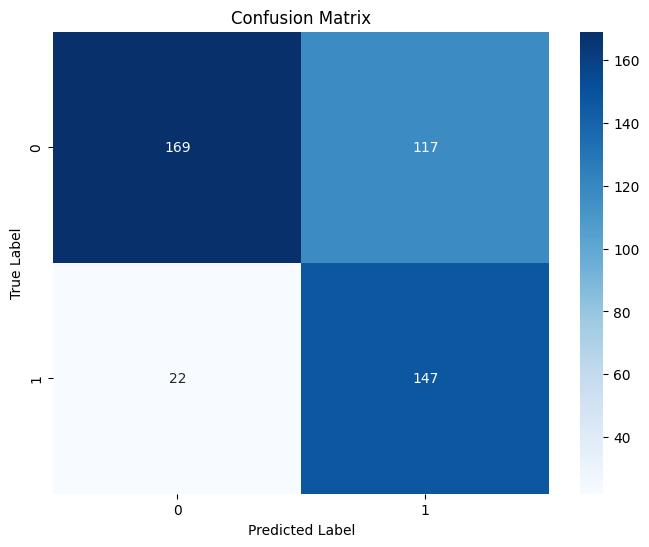


Test Set Performance:

Model Performance Metrics:
Accuracy: 0.8509
Precision: 0.7500
Recall: 0.9070
F1 Score: 0.8211


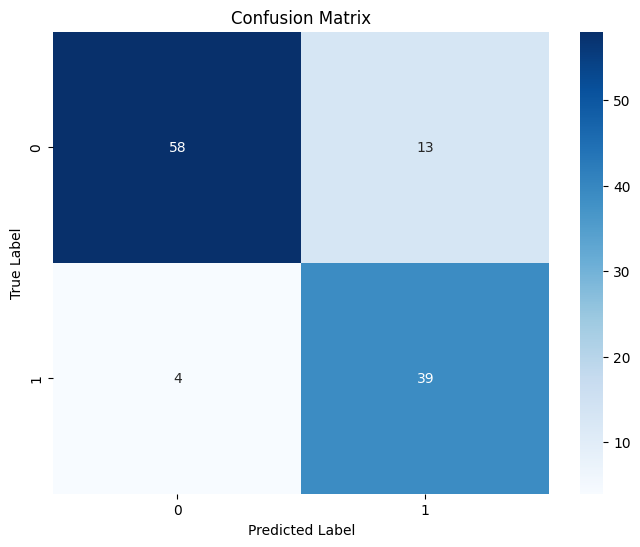

In [21]:
# Evaluate model performance
def evaluate_model(X, y_true, params):
    # Make predictions
    y_pred_prob, _ = forward_propagation(X, params)
    y_pred = (y_pred_prob >= 0.3).astype(int)
    
    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print("\nModel Performance Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Evaluate on both training and test sets
print("\nTraining Set Performance:")
evaluate_model(X_train_scaled, y_train, params)

print("\nTest Set Performance:")
evaluate_model(X_test_scaled, y_test, params)

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
print("LogReg Accuracy:", lr.score(X_test_scaled, y_test))


LogReg Accuracy: 0.9736842105263158


Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters: {'hidden_layer_sizes': (32, 16), 'learning_rate': 0.05, 'n_epochs': 500, 'threshold': 0.5}
Best cross-validation score: 0.9601768962744572

Test Set Performance with Best Model:
Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9534883720930233
F1 Score: 0.9761904761904762

Best parameters: {'hidden_layer_sizes': (32, 16), 'learning_rate': 0.05, 'n_epochs': 500, 'threshold': 0.5}
Best cross-validation score: 0.9601768962744572

Test Set Performance with Best Model:
Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9534883720930233
F1 Score: 0.9761904761904762


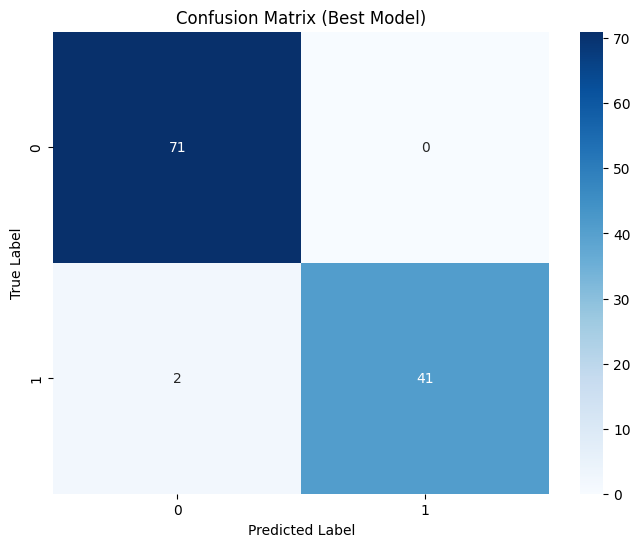

In [23]:
# Create a wrapper class for our neural network to work with GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV

class NeuralNetworkClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(16, 8), learning_rate=0.01, n_epochs=1000, threshold=0.3):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.threshold = threshold
        self.params = None
        
    def _initialize_parameters(self, n_features):
        np.random.seed(42)
        h1, h2 = self.hidden_layer_sizes
        return {
            "W1": np.random.randn(n_features, h1) * np.sqrt(2 / n_features),
            "b1": np.zeros((1, h1)),
            "W2": np.random.randn(h1, h2) * np.sqrt(2 / h1),
            "b2": np.zeros((1, h2)),
            "W3": np.random.randn(h2, 1) * np.sqrt(2 / h2),
            "b3": np.zeros((1, 1)),
        }
    
    def fit(self, X, y):
        # Initialize parameters
        self.params = self._initialize_parameters(X.shape[1])
        
        # Convert data to numpy arrays
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        
        # Training loop
        for epoch in range(self.n_epochs):
            y_hat, cache = forward_propagation(X, self.params)
            grads = backward_propagation(X, y, self.params, cache)
            self.params = update_parameters(self.params, grads, self.learning_rate)
        
        return self
    
    def predict_proba(self, X):
        X = np.array(X)
        probas, _ = forward_propagation(X, self.params)
        return np.hstack([1 - probas, probas])  # Return probabilities for both classes
    
    def predict(self, X):
        probas = self.predict_proba(X)
        return (probas[:, 1] >= self.threshold).astype(int)

# Define parameter grid
param_grid = {
    'hidden_layer_sizes': [(16, 8), (32, 16), (64, 32)],
    'learning_rate': [0.001, 0.01, 0.05],
    'n_epochs': [500, 1000, 1500],
    'threshold': [0.3, 0.4, 0.5]
}

# Create and fit GridSearchCV
nn_classifier = NeuralNetworkClassifier()
grid_search = GridSearchCV(
    estimator=nn_classifier,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

# Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# Print results
print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print("\nTest Set Performance with Best Model:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Plot confusion matrix for best model
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Best Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [24]:
#could add batch gradient WHEN LARGE DATASETS descent or early stopping IF OVERFITTING to improve training efficiency

In [25]:
from joblib import dump, load

# Save the best model from grid search
model_filename = 'breast_cancer_neural_network.joblib'
dump(best_model, model_filename)
print(f"Model saved to {model_filename}")

Model saved to breast_cancer_neural_network.joblib
